# PIMA INDIANS DIABETES DATASET
## Objective
The goal of this analysis is to explore the relationships between medical variables such as glucose, BMI, and insulin, and determine how they relate to diabetes outcomes.
## Dataset Overview
The dataset contains medical diagnostic measurements including glucose level, blood pressure, skin thickness, insulin, BMI, and diabetes outcome.


Import necessary libraries and toolkits

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Reading the .csv file into a dataframe, labelled 'df' using pandas

In [2]:
df = pd.read_csv("diabetes.csv")

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Data Inspection
First, inspect the structure of the dataset, observing for abnormalities including data types, missing values, and summary statistics.

In [3]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Blood pressure, Skin thickness, Insulin, and BMI display physiologically impossible values of zero indicating its likely use as a missing value placeholder.


Variables that are physiologically impossible to have measurements of zero:
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI

Variables that should not have zero values according to dataset description:
- Age (minimum age = 21)

Variables where zero is realistic:
- Pregnancies
- Diabetes Pedigree
- Outcome (binary classification: 0/1)


Further inspection using:
1. .info() - determine presence of NaN values, 
2. .describe() to find minimum values of zero in other 'impossible variables' such as Glucose.

In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



No null values detected.

Glucose confirmed to have a minimum value of zero, along with variables Blood Pressure, Skin Thickness, Insulin, and BMI.

No null values along with physiologically impossible records of zero confirm its use as a missing value placeholder.


**Limitation:**

Concern raised on whether zero values in plausible variables like Pregnacies are truly zero or also placeholders.


It is only possible to covert variables "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI" to missing because of the physiological impossibility for the values to be zero


Replacing zero values in columns "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI" to NaN values.
will not replace Prregnancies and Outcomes with NaN values, because zeros are possible.




In [5]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

df[cols]

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,NaN,33.6
1,85.0,66.0,29.0,NaN,26.6
2,183.0,64.0,NaN,NaN,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1
...,...,...,...,...,...
763,101.0,76.0,48.0,180.0,32.9
764,122.0,70.0,27.0,NaN,36.8
765,121.0,72.0,23.0,112.0,26.2
766,126.0,60.0,NaN,NaN,30.1


## Preprocessing
Obtaining number of zeros and NaN per variable in dataset to determine preprocessing strategy

In [6]:
# confirming if zeros still present:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print((df[cols] == 0).sum())
print(df.shape)

#checking number of null values in full dataset
print("Number of Null values in dataset")
df.isna().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
(768, 9)
Number of Null values in dataset


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total number of records = 768

Skin Thickness and Insulin display high number of missing values.

Skin Thickness - 227(out of 768)

Insulin - 374(out of 768)


In [7]:
print('Skin Thickness:', (227/768)*100)
print('Insulin:', (374/768)*100)


Skin Thickness: 29.557291666666668
Insulin: 48.69791666666667


Approximately 30% of Skin Thickness and 49% of Insulin values are missing in the dataset.

Mean values are less reliable as replacements in this case as it can significantly distort distribution and reduce variablity, particularly for vital diabetes-related variables like Insulin, where nearly half of the values are missing. Alternatives like the median would be more appropriate, as they are less sensitivee to outliers and skewdness.
However, further exploratory analysis is required to assess whether missingness is consistent with the Missing Completely at Random (MCAR) assumption by examining its patterns and relationships with observed variables, helping to  guide the selection of appropriate imputation strategies.

There are three possible reasons for missing values:
1. Missing completely at random - missingness is completely by chance and unrelated to observed data.
2. Missing at random - missingness depends on observed variables in the dataset.
3. Missing not at random - missingness depends on the unobserved value itself.

I can determine either 2 or 3 by looking for correlations/relationships between the missing values and other variables for those patients.

How many patients with missing Skin Thickness values also had missing Insulin values?

In [8]:
stin = df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna())]

stin

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1
10,4,110.0,92.0,NaN,NaN,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
757,0,123.0,72.0,NaN,NaN,36.3,0.258,52,1
758,1,106.0,76.0,NaN,NaN,37.5,0.197,26,0
759,6,190.0,92.0,NaN,NaN,35.5,0.278,66,1
762,9,89.0,62.0,NaN,NaN,22.5,0.142,33,0


All 227 patients with missing Skin Thickness values also observed to have missing Insulin values, indicating a structured pattern of missingness ie: variables could have been collected together, providing additional support that missingness could not have been completely at random.


Note however the reverse is not true as the remaining 147 patients with missing insulin values did not exhibit missing SkinThickness values, this indicates a form of subset of missingness, such that Skin thickness missingness is a subset of Insulin missingness.



In [9]:
#df[(df["Insulin"] == 0).drop
   
# the remianing 147 patients with missing insulin values but no missing SkinThickness values.
insulin_only = df.loc[(df["SkinThickness"].notna()) & (df["Insulin"].isna())]

insulin_only



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
23,9,119.0,80.0,35.0,NaN,29.0,0.263,29,1
30,5,109.0,75.0,26.0,NaN,36.0,0.546,60,0
34,10,122.0,78.0,31.0,NaN,27.6,0.512,45,0
...,...,...,...,...,...,...,...,...,...
754,8,154.0,78.0,32.0,NaN,32.4,0.443,45,1
756,7,137.0,90.0,41.0,NaN,32.0,0.391,39,0
761,9,170.0,74.0,31.0,NaN,44.0,0.403,43,1
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0


The remaining 147 grouped by outcome

In [10]:
#remaining 147 patients with only insulin 0
((df["SkinThickness"].notna()) & (df["Insulin"].isna())).groupby(df['Outcome']).sum()

Outcome
0    97
1    50
dtype: int64

In [11]:

# 227 patients with Insulin and Skin thickness = 0
skin_only = (df["SkinThickness"].isna()).groupby(df['Outcome']).sum()

skin_only

Outcome
0    139
1     88
Name: SkinThickness, dtype: int64

The distribution of values between outcomes in both patients with both insulin and skin thsickness values of zero as well as only insulin patients with skin Thickness values of zero does not seem out of place.

Text(0.5, 1.0, 'All others')

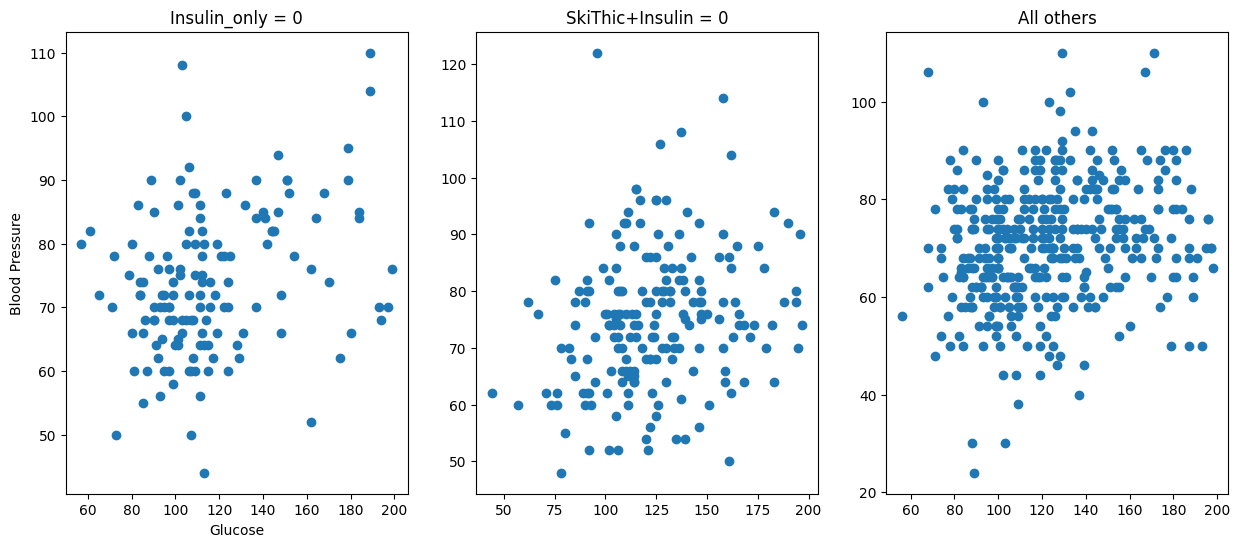

In [12]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]


axes[0].scatter(x = insulin_only["Glucose"], y = insulin_only["BloodPressure"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Glucose")
axes[0].set_ylabel("Blood Pressure")
axes[1].scatter(x = skiin_only["Glucose"], y = skiin_only["BloodPressure"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].scatter(x = others["Glucose"], y = others["BloodPressure"])
axes[2].set_title("All others")




#is there a sort of ditribution among the other variables of these patients compared to the rest of them with no missing insulin or skin values

#sns.displot(data = insulin_only, x = "Glucose", y = "Age", color = "Red", kind = "kde")

Most of the values seem normally distributed, with very faint signal of slight correlation in the third group.
however, 
a horizontal on the y axis = 0 is observed for the second subset with two on the fist.

likely that blood pressure levels were recordd as zero for individuals with missing Insulin and skin thickness values.

In [13]:
df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna())]


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
15,7,100.0,NaN,NaN,NaN,30.0,0.484,32,1
49,7,105.0,NaN,NaN,NaN,NaN,0.305,24,0
60,2,84.0,NaN,NaN,NaN,NaN,0.304,21,0
78,0,131.0,NaN,NaN,NaN,43.2,0.270,26,1
81,2,74.0,NaN,NaN,NaN,NaN,0.102,22,0
193,11,135.0,NaN,NaN,NaN,52.3,0.578,40,1
222,7,119.0,NaN,NaN,NaN,25.2,0.209,37,0
261,3,141.0,NaN,NaN,NaN,30.0,0.761,27,1
266,0,138.0,NaN,NaN,NaN,36.3,0.933,25,1


In [14]:
len(df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna())])

33

### Missing Blood Pressure

33 out of 35 of patients with blood pressure = 0 also indicates Skin thickness AND  Insulin levels = 0. Further proving that values were likely recorded togetehr and may not be missing randomly.


This also raises concern of whether other missing variables were also corresponsing to this pattern.

In [15]:
print(len(df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BMI"].isna())]))


print(len(df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna()) & (df["BMI"].isna())]))


print(len(df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["Glucose"].isna())]))


print(len(df.loc[(df["SkinThickness"].isna()) & (df["Insulin"].isna()) & (df["BloodPressure"].isna()) & (df["Glucose"].isna())]))

9
7
0
0


### Missing BMI
9/11 patients with missing BMI values also had missing values for insulin and skin thickness.

7/11 of them had values missing for Insulin, Skin Thickness and blood pressure.


### Missing Glucose
the 5 patients with missing glucose values however, DID NOT follow this trend, showing likelihood that those missing values were truly random. 

how can i determine if the missing values were as a result of other variables?

Text(0.5, 1.0, 'All others')

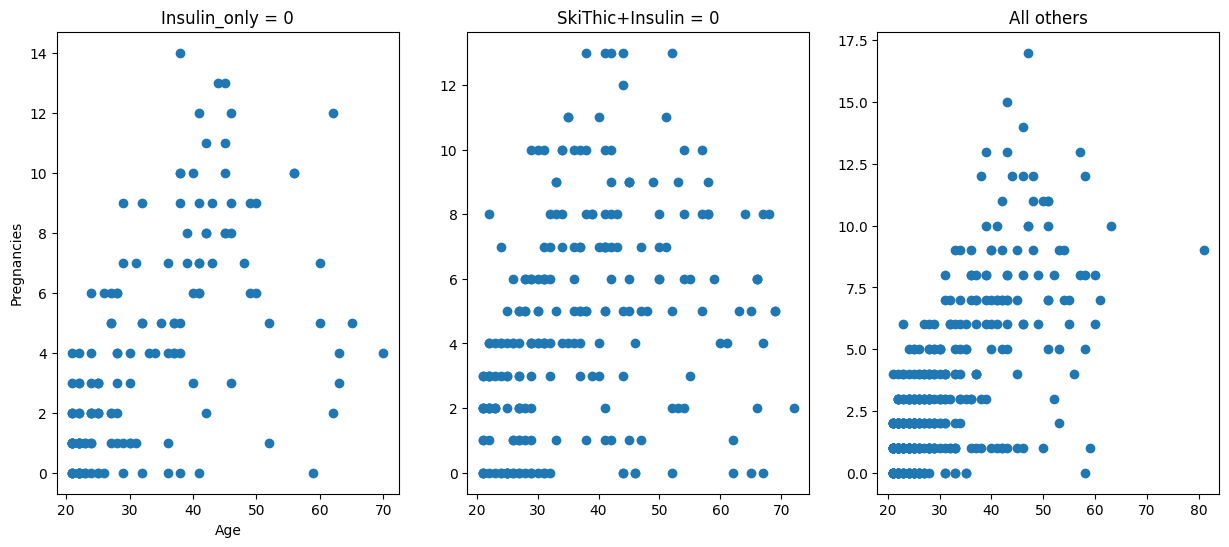

In [16]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]


axes[0].scatter(y = insulin_only["Pregnancies"], x = insulin_only["Age"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Pregnancies")
axes[1].scatter(y = skiin_only["Pregnancies"], x = skiin_only["Age"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].scatter(y = others["Pregnancies"], x = others["Age"])
axes[2].set_title("All others")

Text(0.5, 1.0, 'All others')

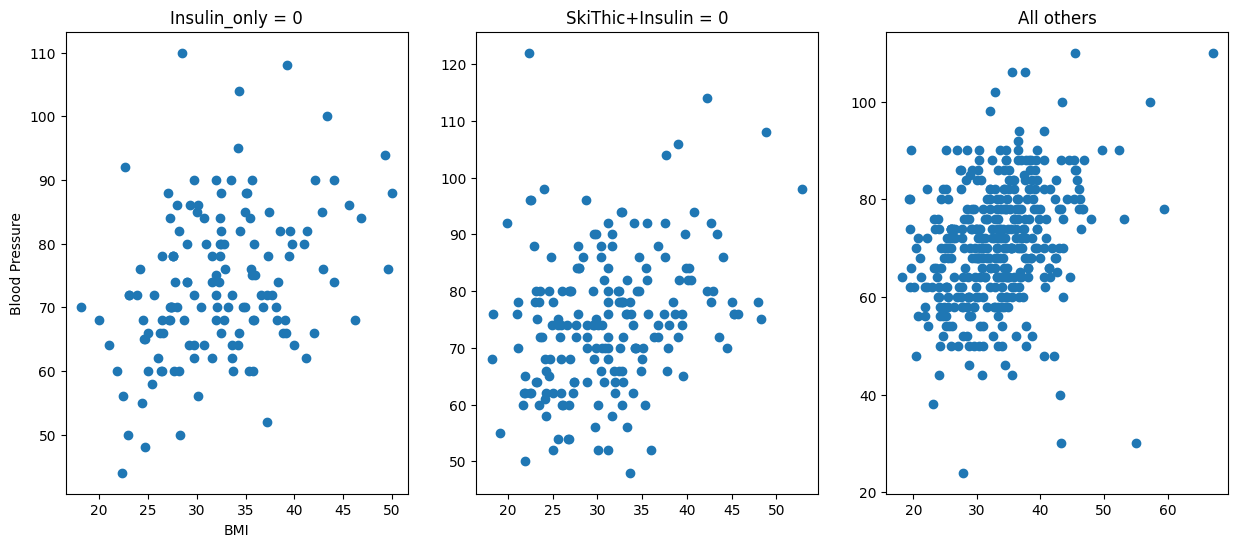

In [17]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]


axes[0].scatter(x = insulin_only["BMI"], y = insulin_only["BloodPressure"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Blood Pressure")
axes[1].scatter(x = skiin_only["BMI"], y = skiin_only["BloodPressure"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].scatter(x = others["BMI"], y = others["BloodPressure"])
axes[2].set_title("All others")

I can be certain that the missing vlaues were not at randome, but i cannot be certain that they were as a result of other values. 

Text(0.5, 1.0, 'All others')

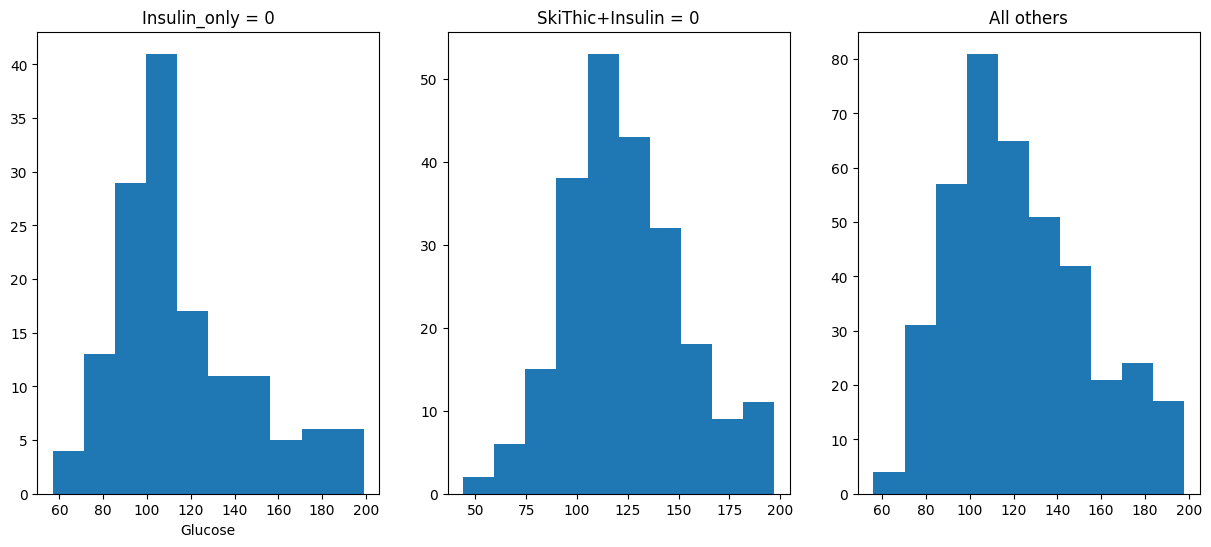

In [18]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]


axes[0].hist(x = insulin_only["Glucose"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Glucose")
axes[1].hist(x = skiin_only["Glucose"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].hist(x = others["Glucose"])
axes[2].set_title("All others")





Text(0.5, 1.0, 'All others')

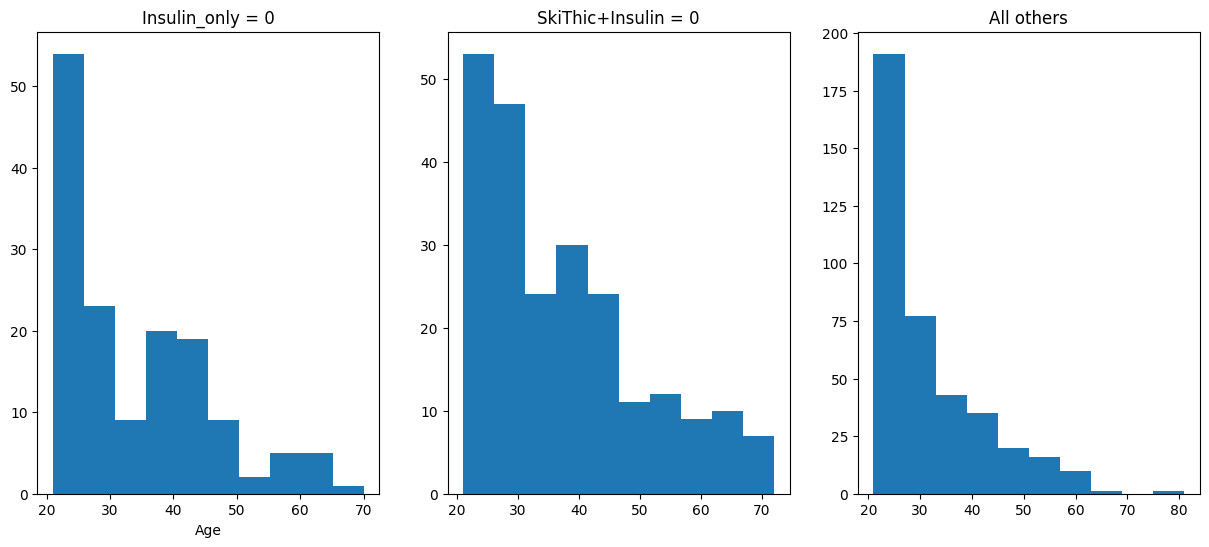

In [19]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]

axes[0].hist(x = insulin_only["Age"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Age")
axes[1].hist(x = skiin_only["Age"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].hist(x = others["Age"])
axes[2].set_title("All others")


In [20]:
insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]



print("miss val for insulin only aged 45+:", (insulin_only["Age"] >= 45).sum(), "/147")
print("miss val for skinthickness and insulin only aged 45+:", (skiin_only["Age"] >= 45).sum(), "/227")
print("miss val for all other except missing insulin and skinthickness aged 45+:", (others["Age"] >= 45).sum(), "/394")



print("Converting to percentages for each subgroup...")



print("miss val for insulin only aged 45+:", (((insulin_only["Age"] >= 45).sum())/147)*100, "%")
print("miss val for skinthickness and insulin only aged 45+:", (((skiin_only["Age"] >= 45).sum())/227)*100, "%")
print("miss val for all other except missing insulin and skinthickness aged 45+:", (((others["Age"] >= 45).sum())/394)*100, "%")

miss val for insulin only aged 45+: 27 /147
miss val for skinthickness and insulin only aged 45+: 58 /227
miss val for all other except missing insulin and skinthickness aged 45+: 48 /394
Converting to percentages for each subgroup...
miss val for insulin only aged 45+: 18.367346938775512 %
miss val for skinthickness and insulin only aged 45+: 25.55066079295154 %
miss val for all other except missing insulin and skinthickness aged 45+: 12.18274111675127 %


nothing here...

Text(0.5, 1.0, 'All others')

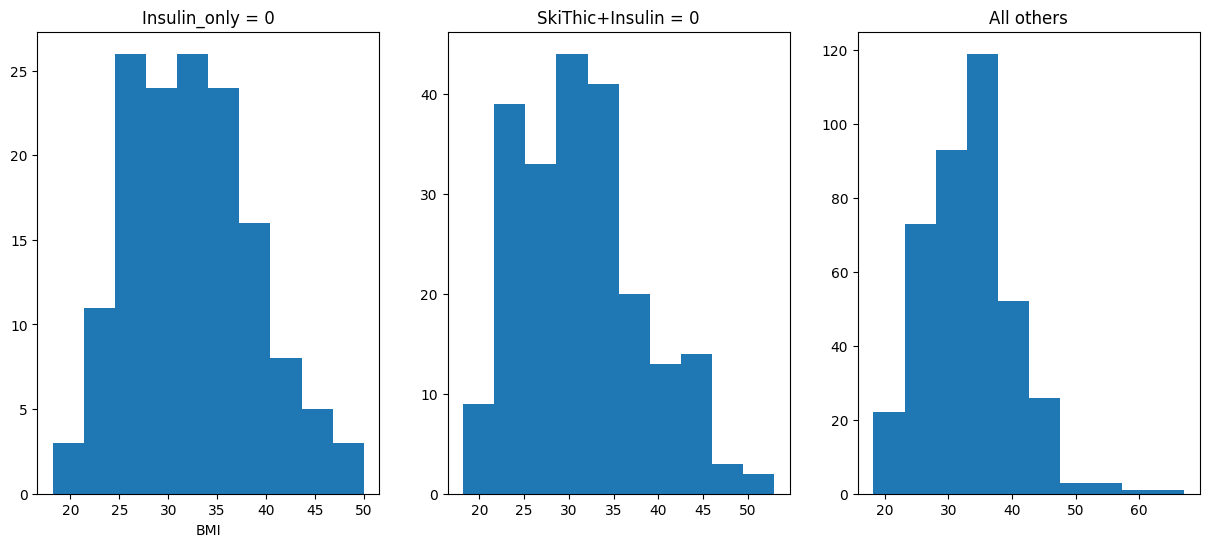

In [21]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]


axes[0].hist(x = insulin_only["BMI"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("BMI")
axes[1].hist(x = skiin_only["BMI"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].hist(x = others["BMI"])
axes[2].set_title("All others")


Text(0.5, 1.0, 'All others')

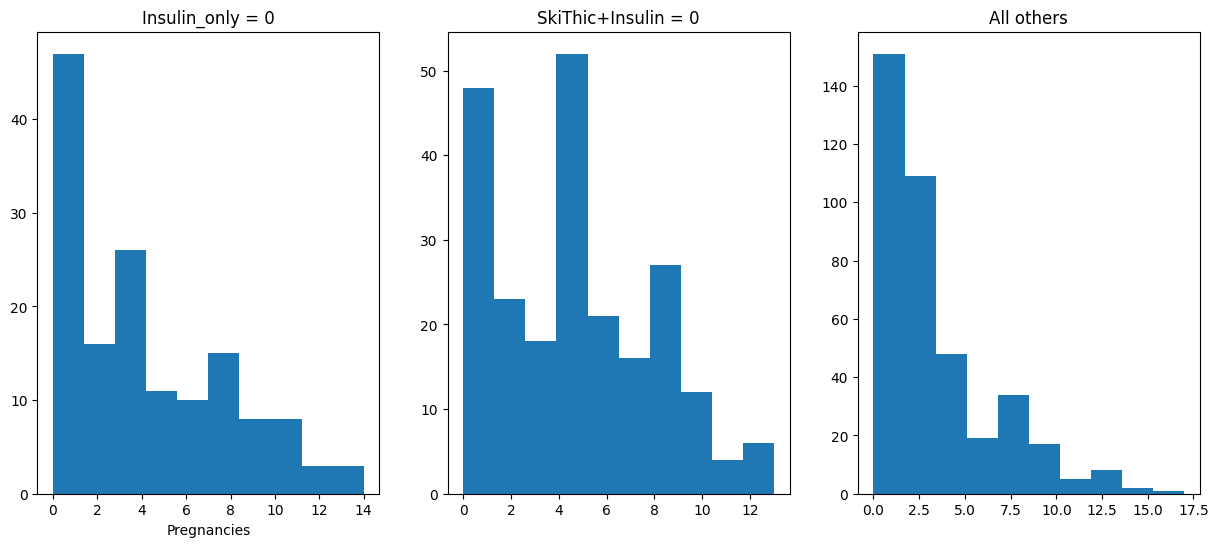

In [22]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]



axes[0].hist(x = insulin_only["Pregnancies"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Pregnancies")
axes[1].hist(x = skiin_only["Pregnancies"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].hist(x = others["Pregnancies"])
axes[2].set_title("All others")


A larger amount of women with both Insulin and Skin thickness values of zero seemed to have more than 4 pregnancies

In [23]:
insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]



print("miss val for insulin only with preg. > 4:", (insulin_only["Pregnancies"] > 4).sum(), "/147")
print("miss val for skinthickness and insulin only with preg. > 4:", (skiin_only["Pregnancies"] > 4).sum(), "/227")
print("miss val for all other except missing insulin and skinthickness with preg. > 4:", (others["Pregnancies"] > 4).sum(), "/394")



print("Converting to percentages for each subgroup...")



print("miss val for insulin only with preg. > 4:", (((insulin_only["Pregnancies"] > 4).sum())/147)*100, "%")
print("miss val for skinthickness and insulin only with preg. > 4:", (((skiin_only["Pregnancies"] > 4).sum())/227)*100, "%")
print("miss val for all other except missing insulin and skinthickness with preg. > 4:", (((others["Pregnancies"] > 4).sum())/394)*100, "%")

miss val for insulin only with preg. > 4: 58 /147
miss val for skinthickness and insulin only with preg. > 4: 111 /227
miss val for all other except missing insulin and skinthickness with preg. > 4: 107 /394
Converting to percentages for each subgroup...
miss val for insulin only with preg. > 4: 39.455782312925166 %
miss val for skinthickness and insulin only with preg. > 4: 48.89867841409692 %
miss val for all other except missing insulin and skinthickness with preg. > 4: 27.157360406091367 %


Number of women with pregnancies greater than 4 seems to be significant in the subgroup of women with BOTH insulin and skinthickness values missing

Text(0.5, 1.0, 'All others')

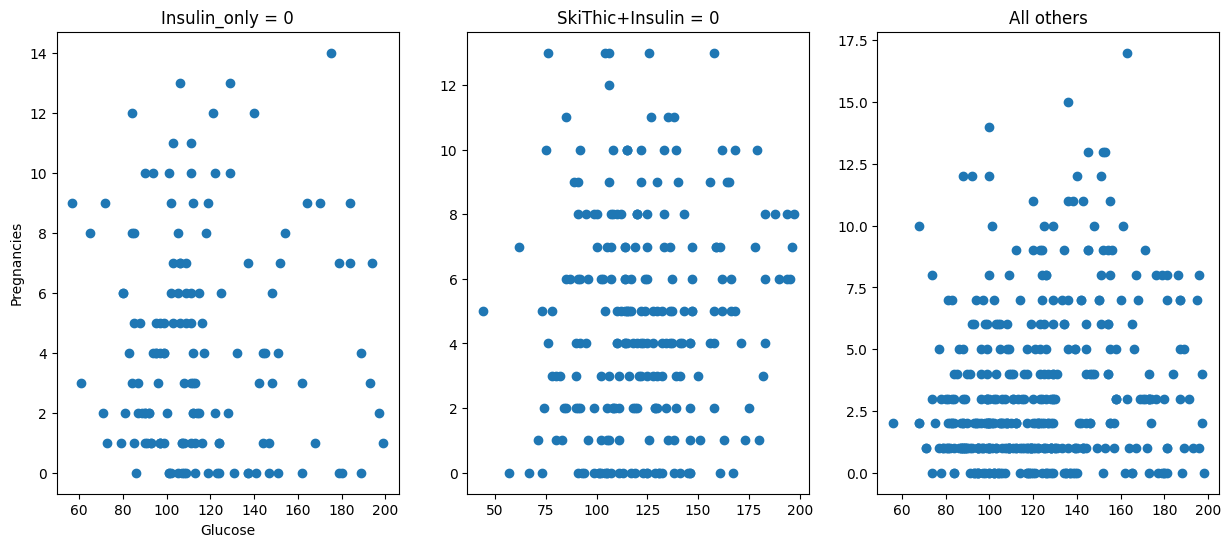

In [24]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]


axes[0].scatter(x = insulin_only["Glucose"], y = insulin_only["Pregnancies"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Glucose")
axes[0].set_ylabel("Pregnancies")
axes[1].scatter(x = skiin_only["Glucose"], y = skiin_only["Pregnancies"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].scatter(x = others["Glucose"], y = others["Pregnancies"])
axes[2].set_title("All others")

Text(0.5, 1.0, 'All others')

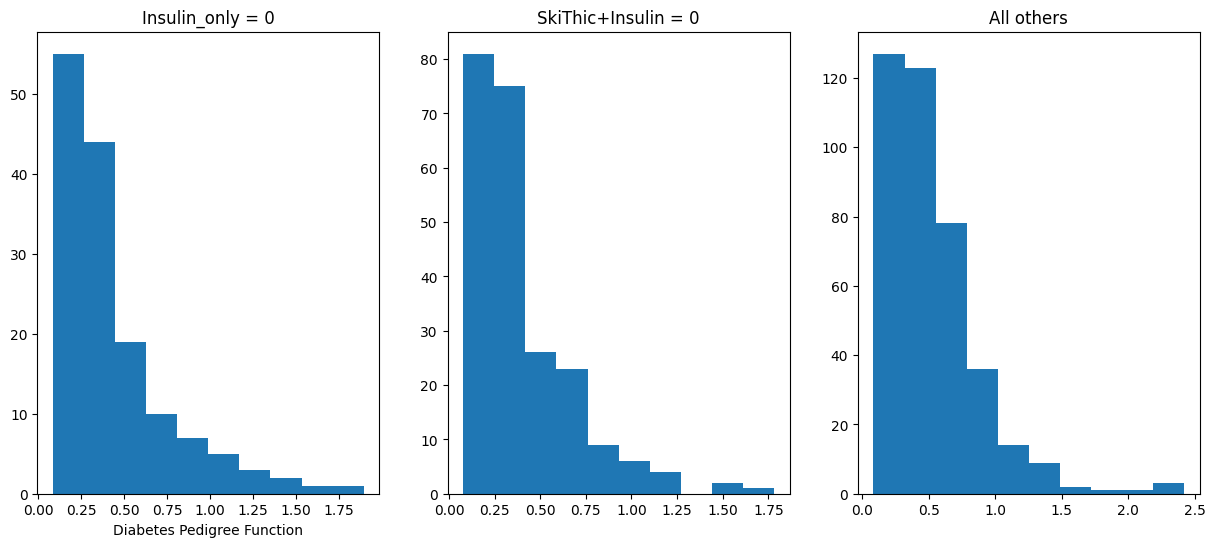

In [25]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]



axes[0].hist(x = insulin_only["DiabetesPedigreeFunction"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Diabetes Pedigree Function")
axes[1].hist(x = skiin_only["DiabetesPedigreeFunction"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].hist(x = others["DiabetesPedigreeFunction"])
axes[2].set_title("All others")

Text(0.5, 1.0, 'All others')

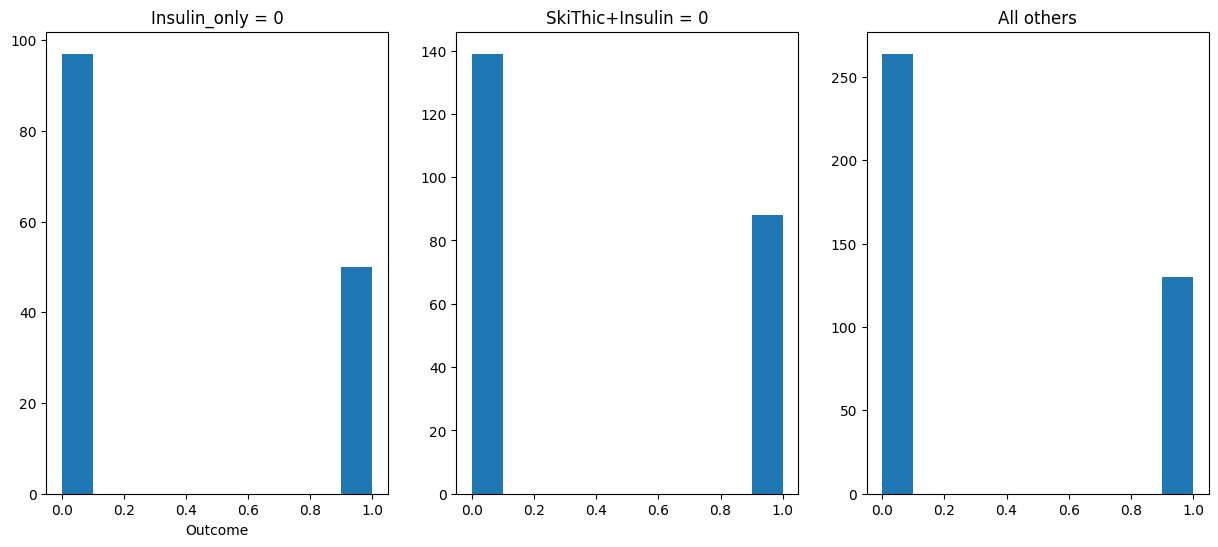

In [26]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]



axes[0].hist(x = insulin_only["Outcome"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Outcome")
axes[1].hist(x = skiin_only["Outcome"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].hist(x = others["Outcome"])
axes[2].set_title("All others")

Text(0.5, 1.0, 'All others')

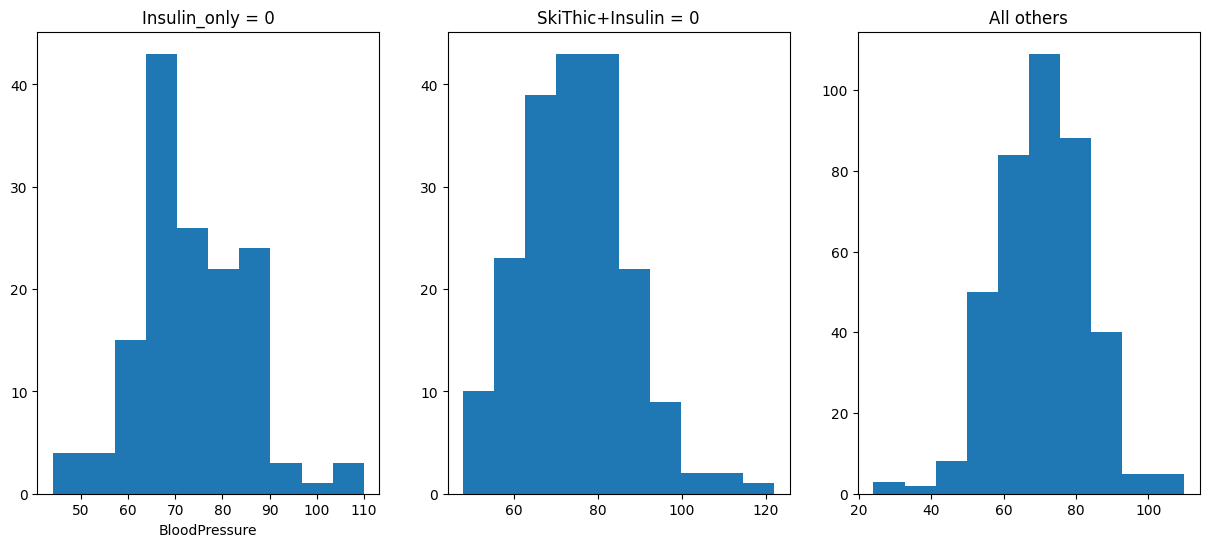

In [27]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]



axes[0].hist(x = insulin_only["BloodPressure"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("BloodPressure")
axes[1].hist(x = skiin_only["BloodPressure"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].hist(x = others["BloodPressure"])
axes[2].set_title("All others")

Text(0.5, 1.0, 'All others')

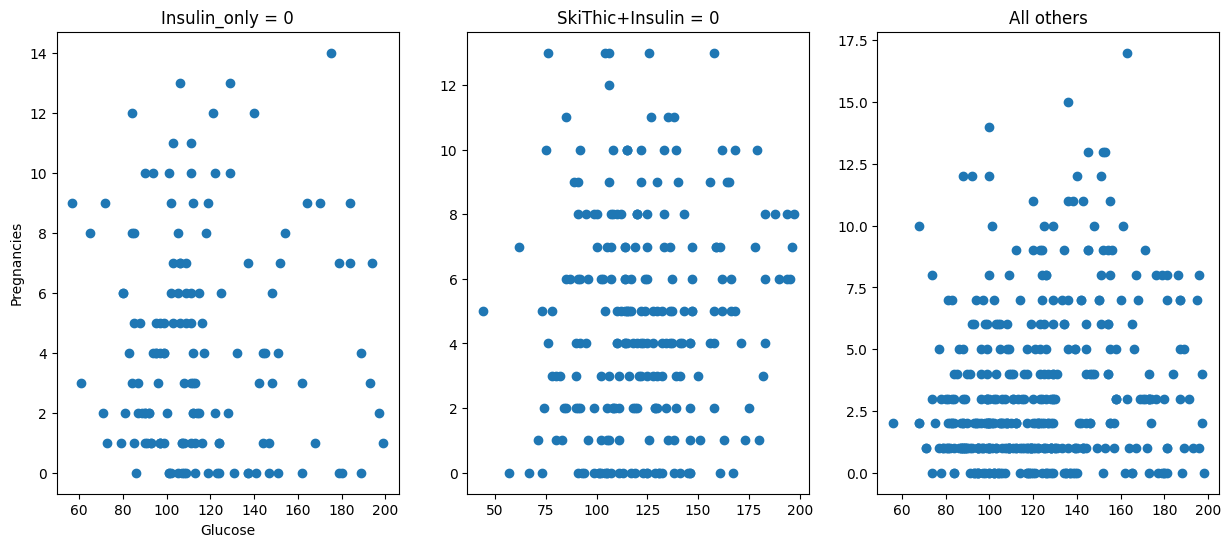

In [28]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

insulin_only = df[((df["SkinThickness"].notna()) & (df["Insulin"].isna()))]
skiin_only = df[((df["SkinThickness"].isna()) & (df["Insulin"].isna()))]
others = df[(df["SkinThickness"].notna()) & (df["Insulin"].notna())]


axes[0].scatter(x = insulin_only["Glucose"], y = insulin_only["Pregnancies"])
axes[0].set_title("Insulin_only = 0")
axes[0].set_xlabel("Glucose")
axes[0].set_ylabel("Pregnancies")
axes[1].scatter(x = skiin_only["Glucose"], y = skiin_only["Pregnancies"])
axes[1].set_title("SkiThic+Insulin = 0")
axes[2].scatter(x = others["Glucose"], y = others["Pregnancies"])
axes[2].set_title("All others")

### Pairplot for the whole data

C:\Users\Me\AppData\Local\Temp\ipykernel_6088\461351636.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


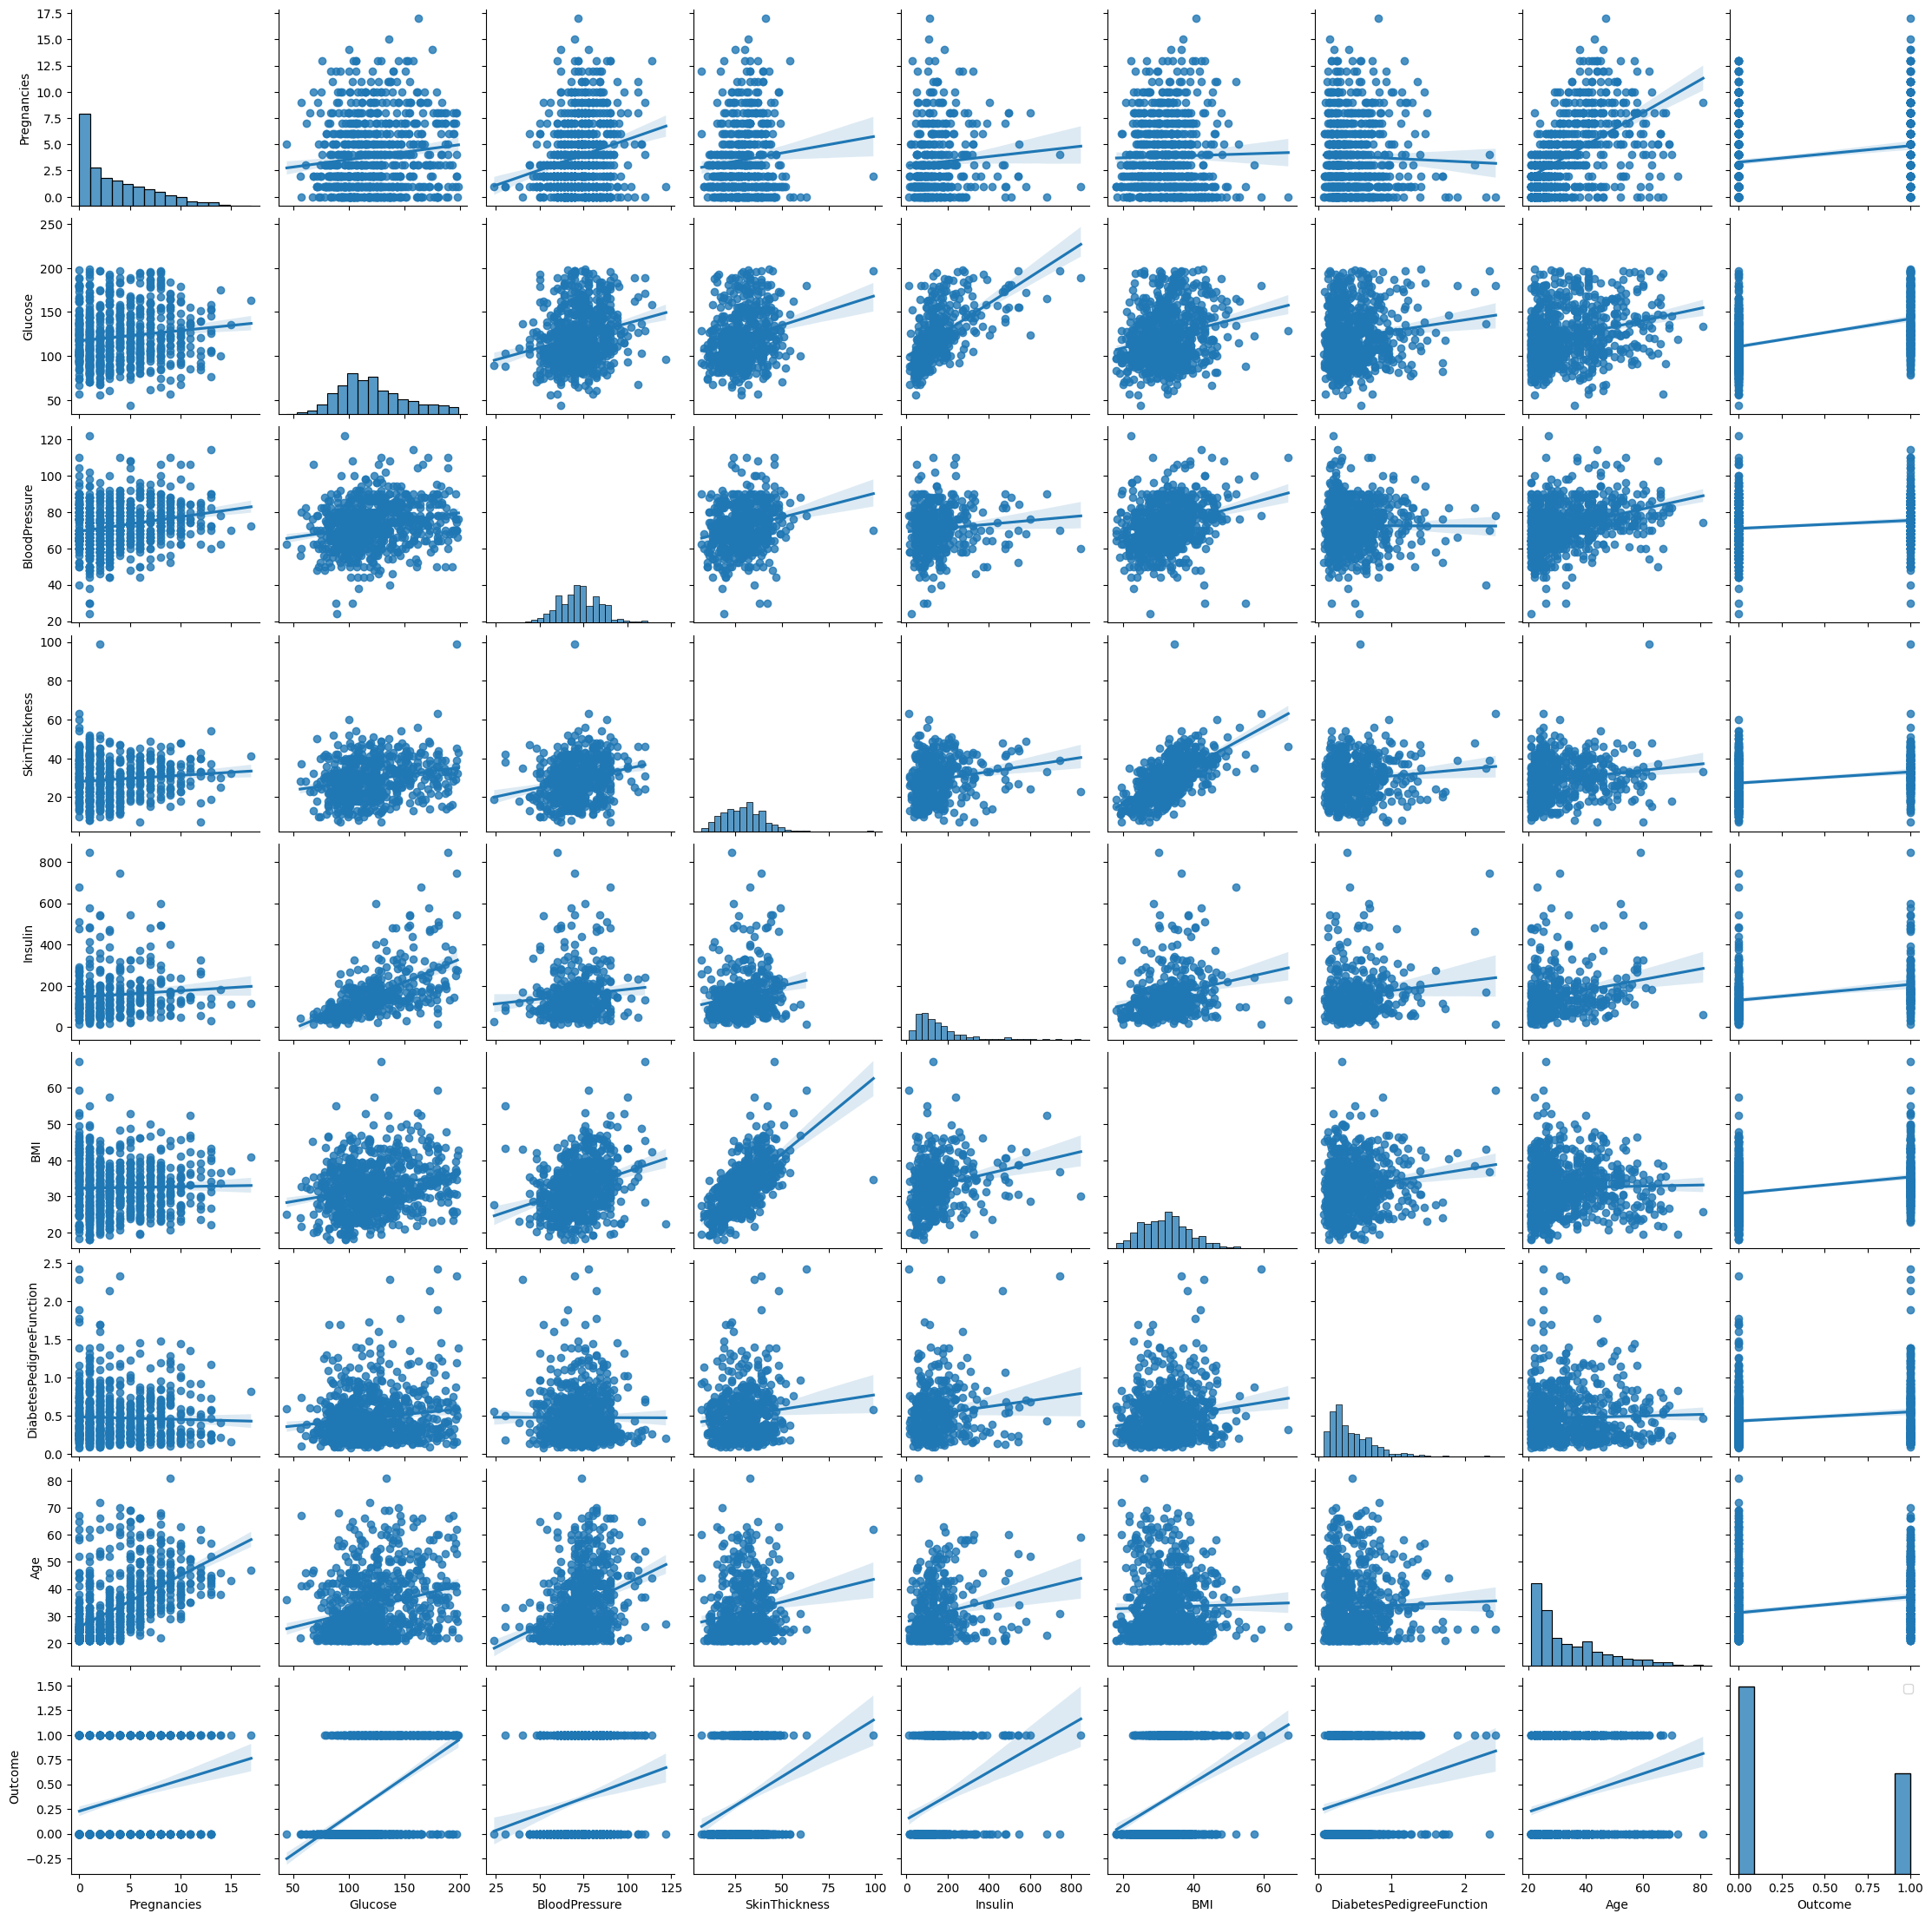

In [29]:
sns.pairplot(data = df, kind = "reg") 
plt.legend()

### Strong slope
1. Age vs Pregnancies - STRONG
3. Skin thickness vs BMI - VERY STRONG


### Moderate Slope 
1. Insulin vs Glucose 

### Others
Everything else is either unknown cloud, vertical or horizontal


Histogram
1. Pregnancies. Right skewed, mostly younger population
2. Glucose. slight right skew
3. Blood pressure - Mostly normal, Higher blood pressures missing
4. SKin thickness - Normal. Population is moostly on the lower end, very clustered to the left
5. Insulin. Strong right skew, long tail.
6. BMI - nearly normal, slight right skew
7. DPF - very high right skew. Most patents with low dpf
8. Age . High right skew. Population is mostly youner
9. More people with an outcome of zero.





### Checking correlations in the whole dataset (including variables with null and zero values) to confirm or filter

In [30]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341,0.221898
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136,0.494650
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107,0.170589
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816,0.259491
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841,0.313680
DiabetesPedigreeFunction,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561,0.173844
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000,0.238356
Outcome,0.221898,0.494650,0.170589,0.259491,0.303454,0.313680,0.173844,0.238356,1.000000


### Strong correlations 0.5+
1. BMI vs Skin Thickness - strong(0.64)
2. Insulin vs Glucose - strong (0.58)
3. Age vs pregnancies - strong (0.54)
4. Glucose vs Outcome - strong (0.49)
The top 3 coincide very strongly with my assumptions when viewed on the pairplot prior to correlation analysis

### Moderate correlations0. 0.3 to 0.4
5. Age vs blood pressure - (0.33)
6. Outcome vs Insulin - (0.30)
7. Outcome vs BMI - (0.30)
moderate R values, would need further comparisons and testing.

### Weak corellations 0.2 to 0.3
8. Blood pressure vs pregnancies - (0.2)
9. Outcome vs Pregnancies - (0.2)
10. Age vs Glucose (0.26)
11. Pregnancies vs BloodPressure (0.21)
12. Glucose vs BloodPressure(0.22)
13. SkinThickness vs Blood Pressure (0.22)
14. BMI vs Blood pressure (0.28)
15. Glucose vs SKin thickness 0.22
16. Blood pressure vs skinthickness 0.22
17. Outcome vs skinthicjness 0.25
18. BMI vs Insulin - 0.22
19. Age vs Insulin - 0.22
20. Outcome vs Age 0.23

Multiple weak correlations observed among metabolic and anthropometric variables (r ≈ 0.2–0.28), likely reflecting shared variance and measurement noise



### Pairplot for patients with missing Insulin values only

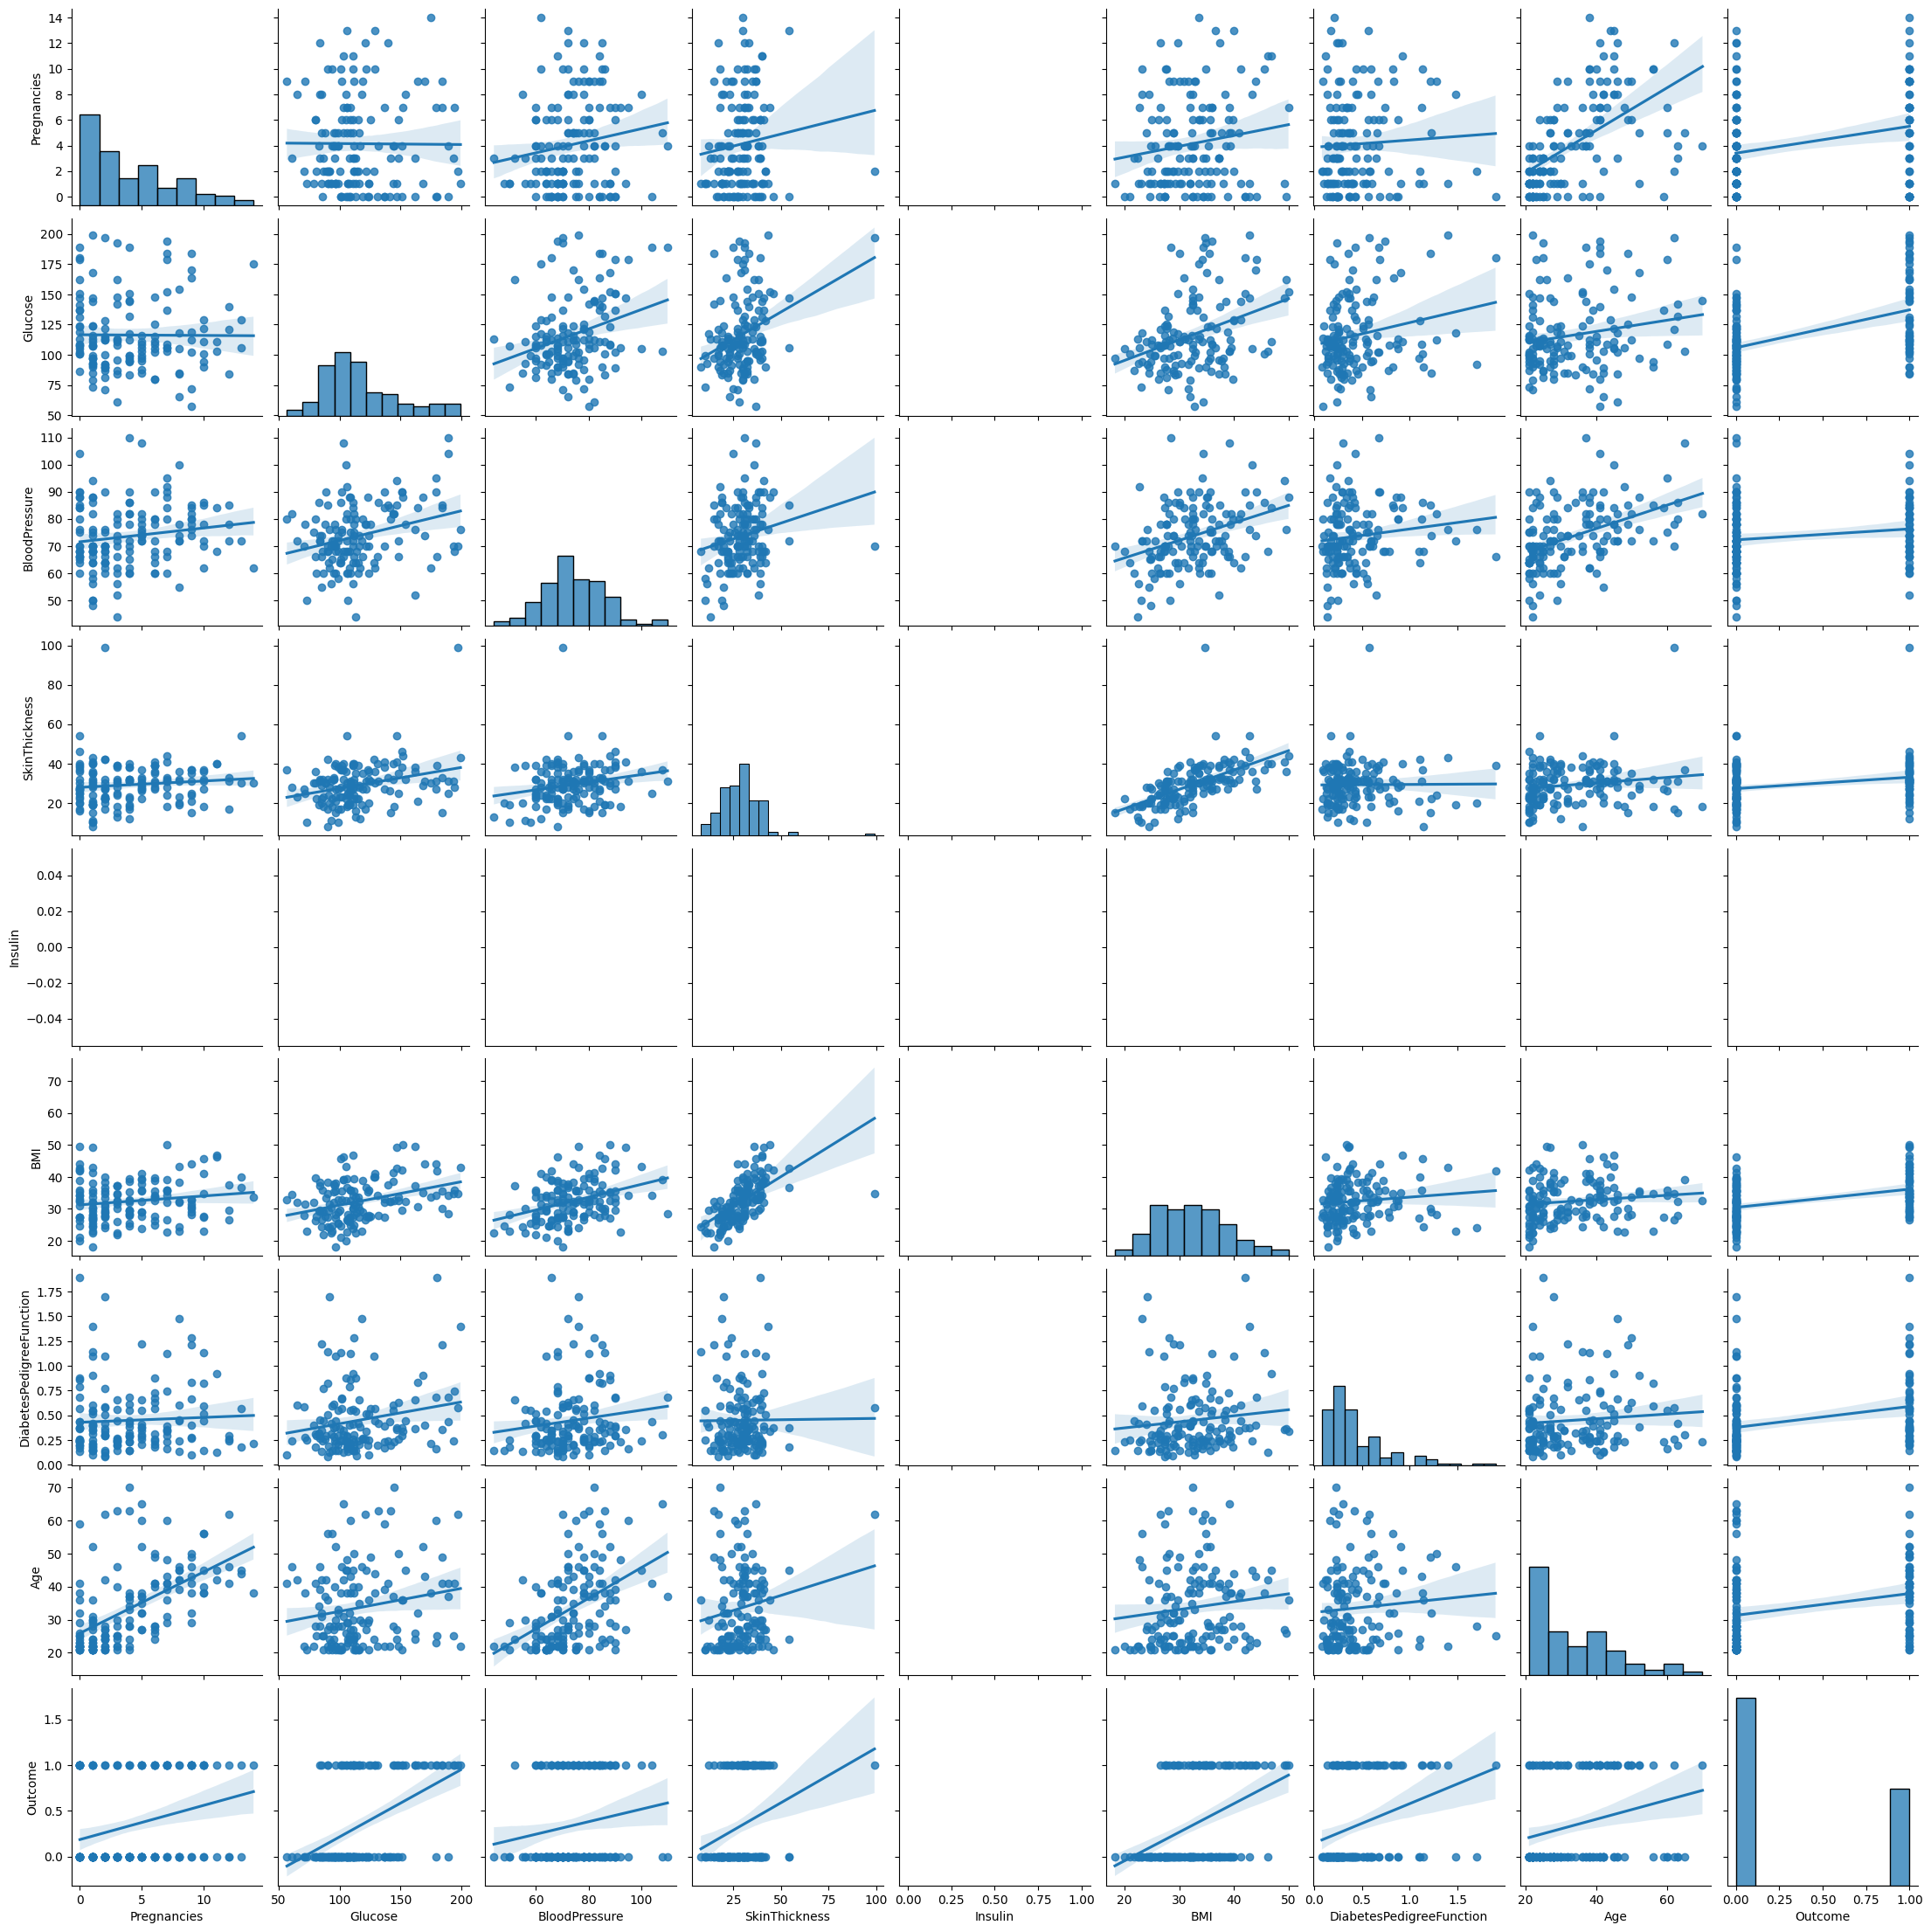

In [31]:
sns.pairplot(data = insulin_only, kind = "reg")


### Positive taper
1. BMI vs Skin Thickness - strong
3. Age vs pregnancies - strong
2. Insulin vs Glucose - NO INSULIN


### Moderate taper
2. Blood Pressure vs BMI
2. Blood pressure vs age 




### VERTICAL/ HORIZONTAL (Others)
1. The others are either clouds or veritical/horizontal

##### HISTOGRAMS
1. Pregnancy - right skewdness - majority of the population have lower pregnancies
2. Glucose - Slight right skewdness, but still a good amoount of values on the right - lower glucose levels?
3. Blood pressure - Almost normal distribution
4. Skin thickness - no values above 50 in this set - slight right skewed but values are clustered on the left.
5. BMI - Slight right skewing, but almost normal distribution.
6. Diabetes Pedigree function - Heavily skewed to the right. values cluster on the left - low amounts of people with DPF of 1
7. Age - very skewed on the right as well, lower amount of patients above 45.
8. Outcome - more people with an outcome of zero, almost twice the size of people with an outcome of 1.


## Checking Correlation for ipopulation of individuals with missing values for nsulin only

In [32]:
insulin_only.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,-0.006603,0.154878,0.110370,NaN,0.153552,0.053009,0.555810,0.280393
Glucose,-0.006603,1.000000,0.296711,0.312756,NaN,0.354077,0.203460,0.180439,0.482318
BloodPressure,0.154878,0.296711,1.000000,0.212609,NaN,0.359339,0.138287,0.446774,0.166172
SkinThickness,0.110370,0.312756,0.212609,1.000000,NaN,0.604160,0.008492,0.160137,0.263720
Insulin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,0.153552,0.354077,0.359339,0.604160,NaN,1.000000,0.118241,0.128640,0.422355
DiabetesPedigreeFunction,0.053009,0.203460,0.138287,0.008492,NaN,0.118241,1.000000,0.085369,0.303086
Age,0.555810,0.180439,0.446774,0.160137,NaN,0.128640,0.085369,1.000000,0.263440
Outcome,0.280393,0.482318,0.166172,0.263720,NaN,0.422355,0.303086,0.263440,1.000000


### Strong corr 0.5+
Age vs Pregnanies 0.55
Skin thickness vs BMI - 0.6
Insulin vs Glucose not in this set, because Glucose values are missing in this subset.

### Modrate corr 0.3 to 0.49
1. Glucose vs Skin thickness 0.31
2. BMI vs glucose 0.35
3. Outcome vs Glucpose - 0.48
4. Age vs Blood pressure 0.44
5. BMI vs blood pressure 0.35
6. Outcome vs BMI - 0.42
7. Outcome vs DPB - 0.30

### Weak cor 0.2 to 0.3
1. outcome vs pregnancies 0.28
2. Blood pressure vs glucose 
3. DPF vs Glucose 0.20
4. Blood pressure vs skin thickness 0.21
5. 


### Notable weaks
1. Glucose vs Pregnancies 

### Pairplot for patients with missingness for both Insulin and SkinThickness

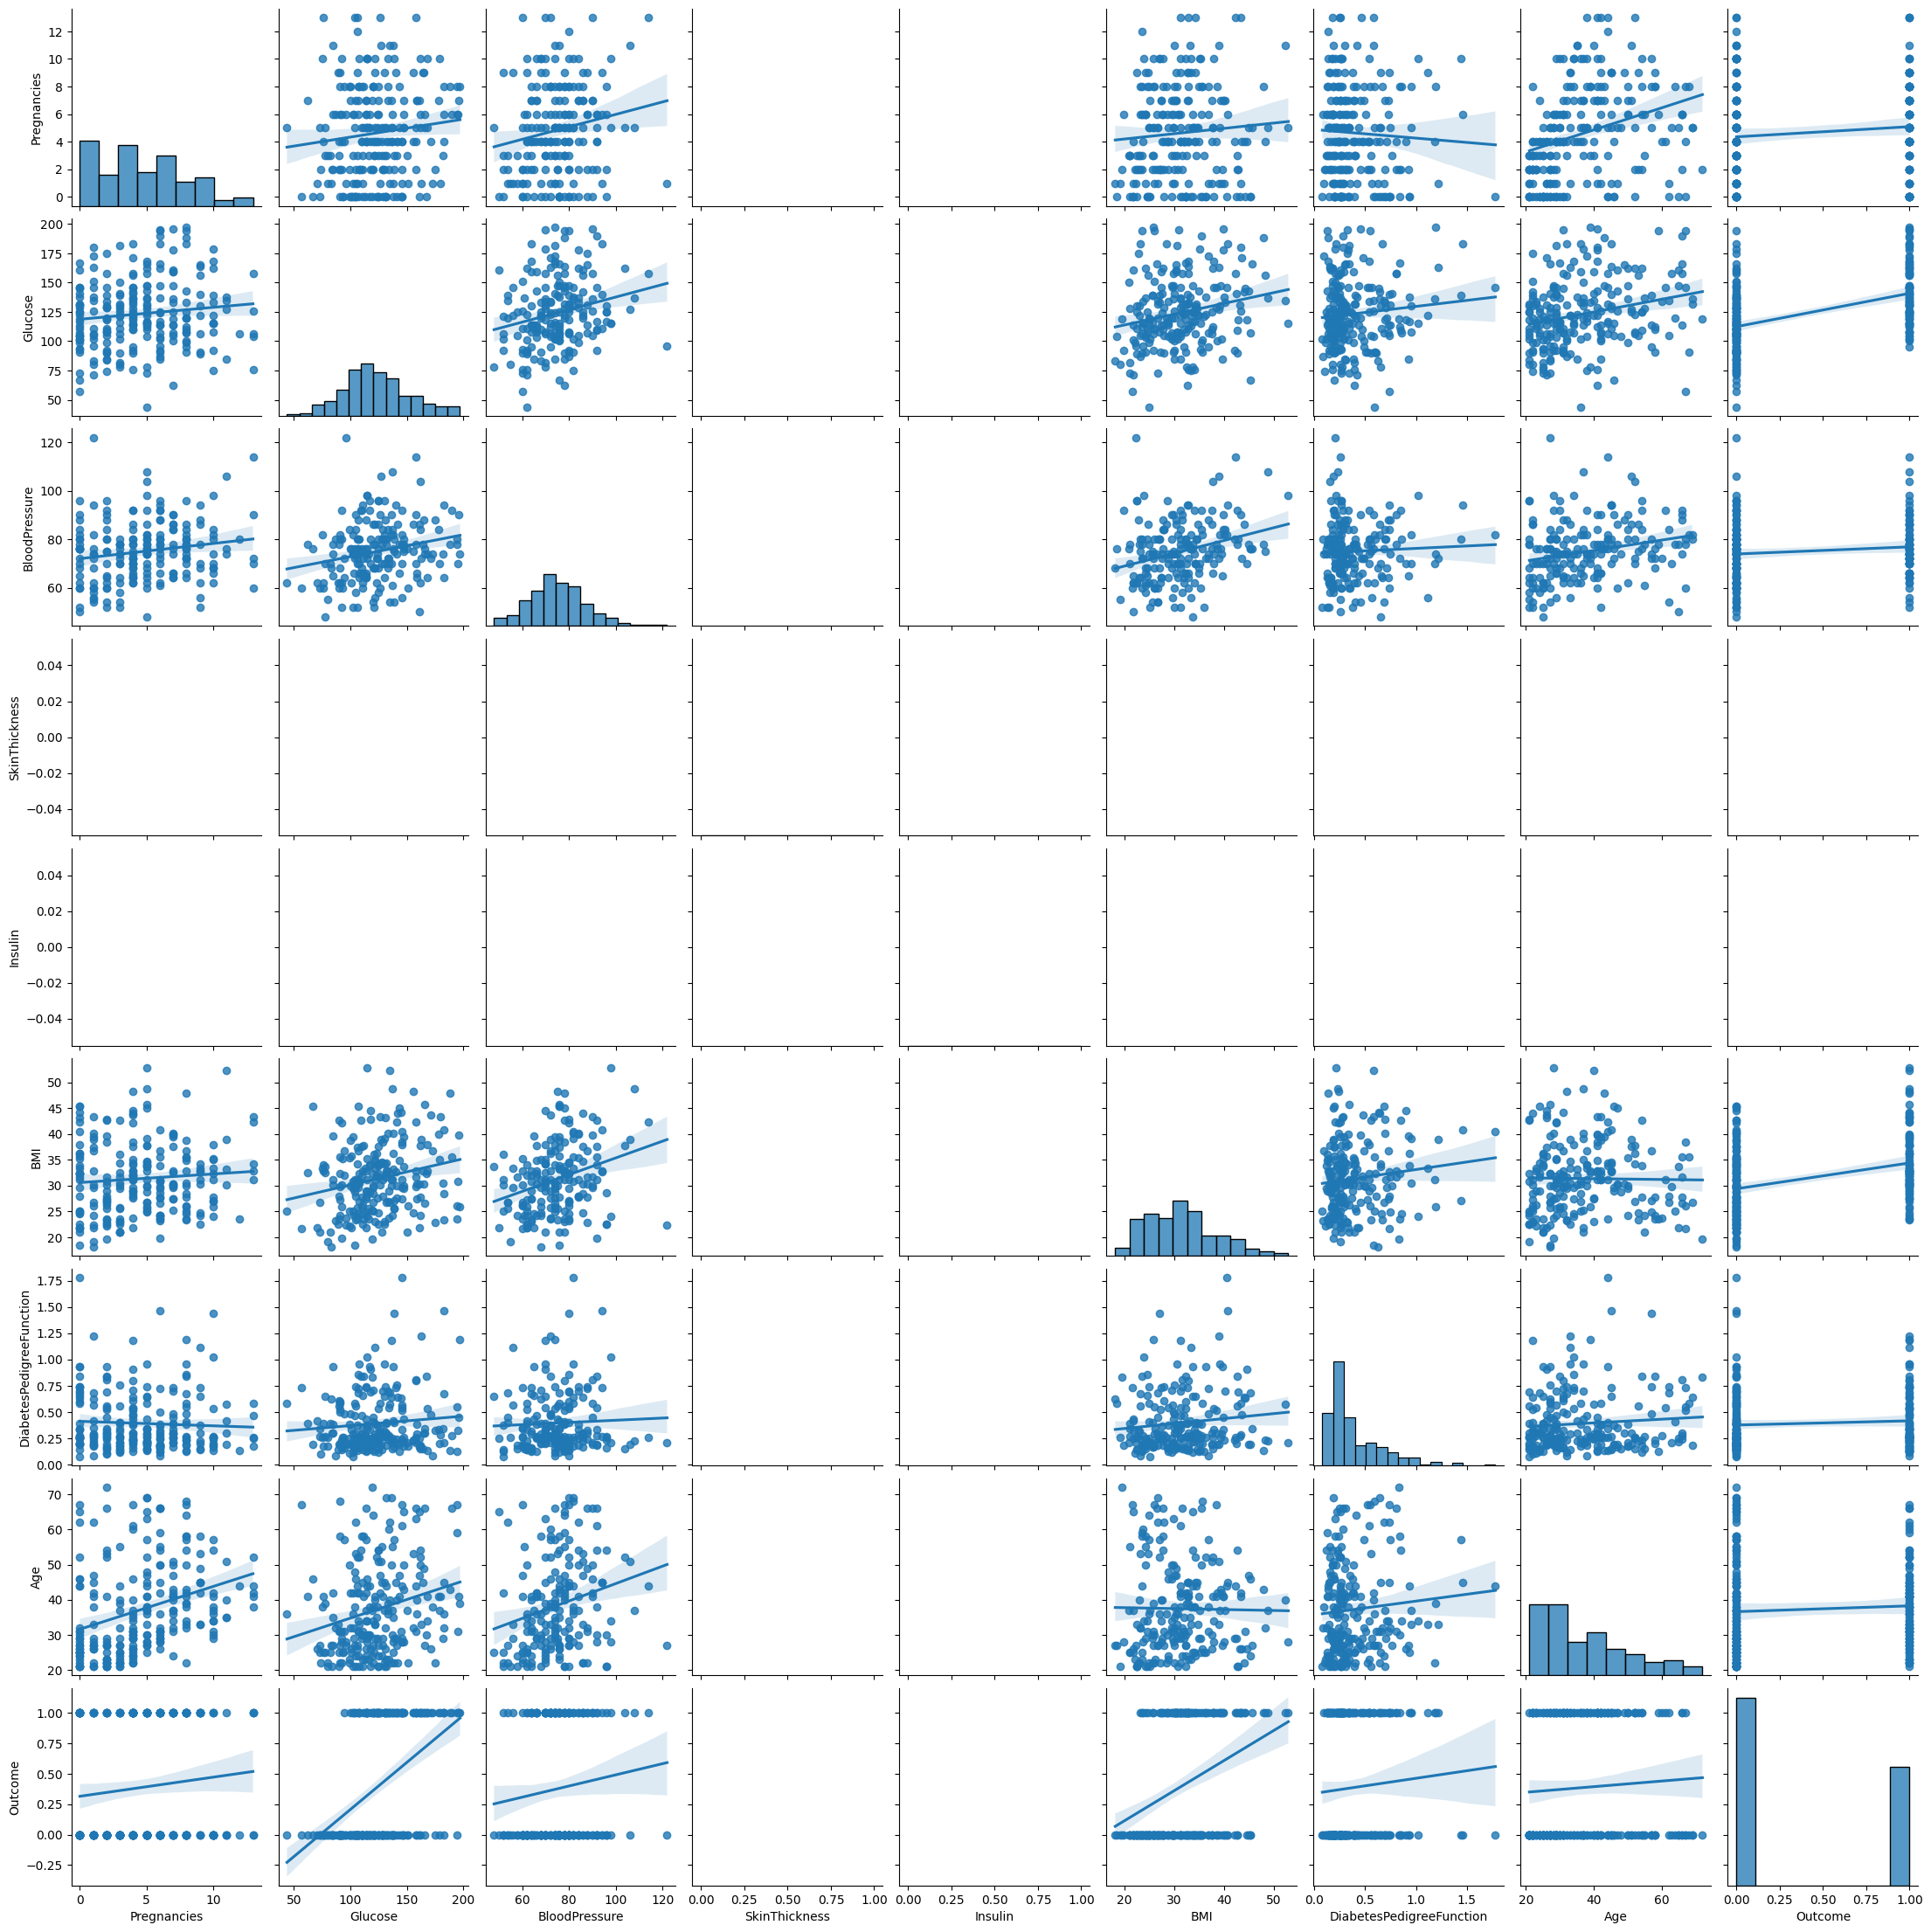

In [40]:
sns.pairplot(data = skiin_only, kind = "reg")

### Strong Tapering
1. Age vs pregnancies - v
2. Blood pressure vs BMI 


### Moderate Tapering 
1. Age vs pregnancies - strong visual signs in Insulin_only and whole data - 
2. BMI vs blood pressure 
3. Age and blood pressure 

### Others 
others are either clouds or vertical/horizontal


##### HISTOGRAMS
1. Pregnancy - right skewdness - majority of the population have lower pregnancies
2. Glucose - Near normal , Slight left skewdness, but still a good amoount of values on the right - fewer people with lower glucose levels
3. Blood pressure - Almost normal distribution
5. BMI - large right skewing
6. Diabetes Pedigree function - Heavily skewed on the right. values cluster on the left - low amounts of people with DPF of 1
7. Age - very skewed on the right as well, lower amount of patients above 45.
8. Outcome - more people with an outcome of zero( patients with outcome of 1 are about 2/3 of the outcome 0 set)



Lower strength in slopes 

### Correlations for values in the subset of patients where both Insulin and Skin thickness vales are missing

In [39]:
skiin_only.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.115044,0.167926,NaN,NaN,0.079981,-0.051560,0.311785,0.107626
Glucose,0.115044,1.000000,0.220311,NaN,NaN,0.216530,0.096376,0.239885,0.469574
BloodPressure,0.167926,0.220311,1.000000,NaN,NaN,0.292650,0.045652,0.230570,0.116268
SkinThickness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insulin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,0.079981,0.216530,0.292650,NaN,NaN,1.000000,0.117317,-0.014426,0.351864
DiabetesPedigreeFunction,-0.051560,0.096376,0.045652,NaN,NaN,0.117317,1.000000,0.082519,0.070250
Age,0.311785,0.239885,0.230570,NaN,NaN,-0.014426,0.082519,1.000000,0.061672
Outcome,0.107626,0.469574,0.116268,NaN,NaN,0.351864,0.070250,0.061672,1.000000


### Strong corr 0.5+

### Moderate corr 0.3 to 0.5
1. Age vs Pregnancies 0.3

### Weak corr 0.2 to 0.3
1. Glucose vs blood pressure
2. blood pressure vs BMI

### Notable negs
1. Diabetes vs prganancies


Correlation has droped significantly as compared to the whole data set and insulin only dataset.

### Pairplot for all other patients who did not have any missing Insulin or Skin Thickness values

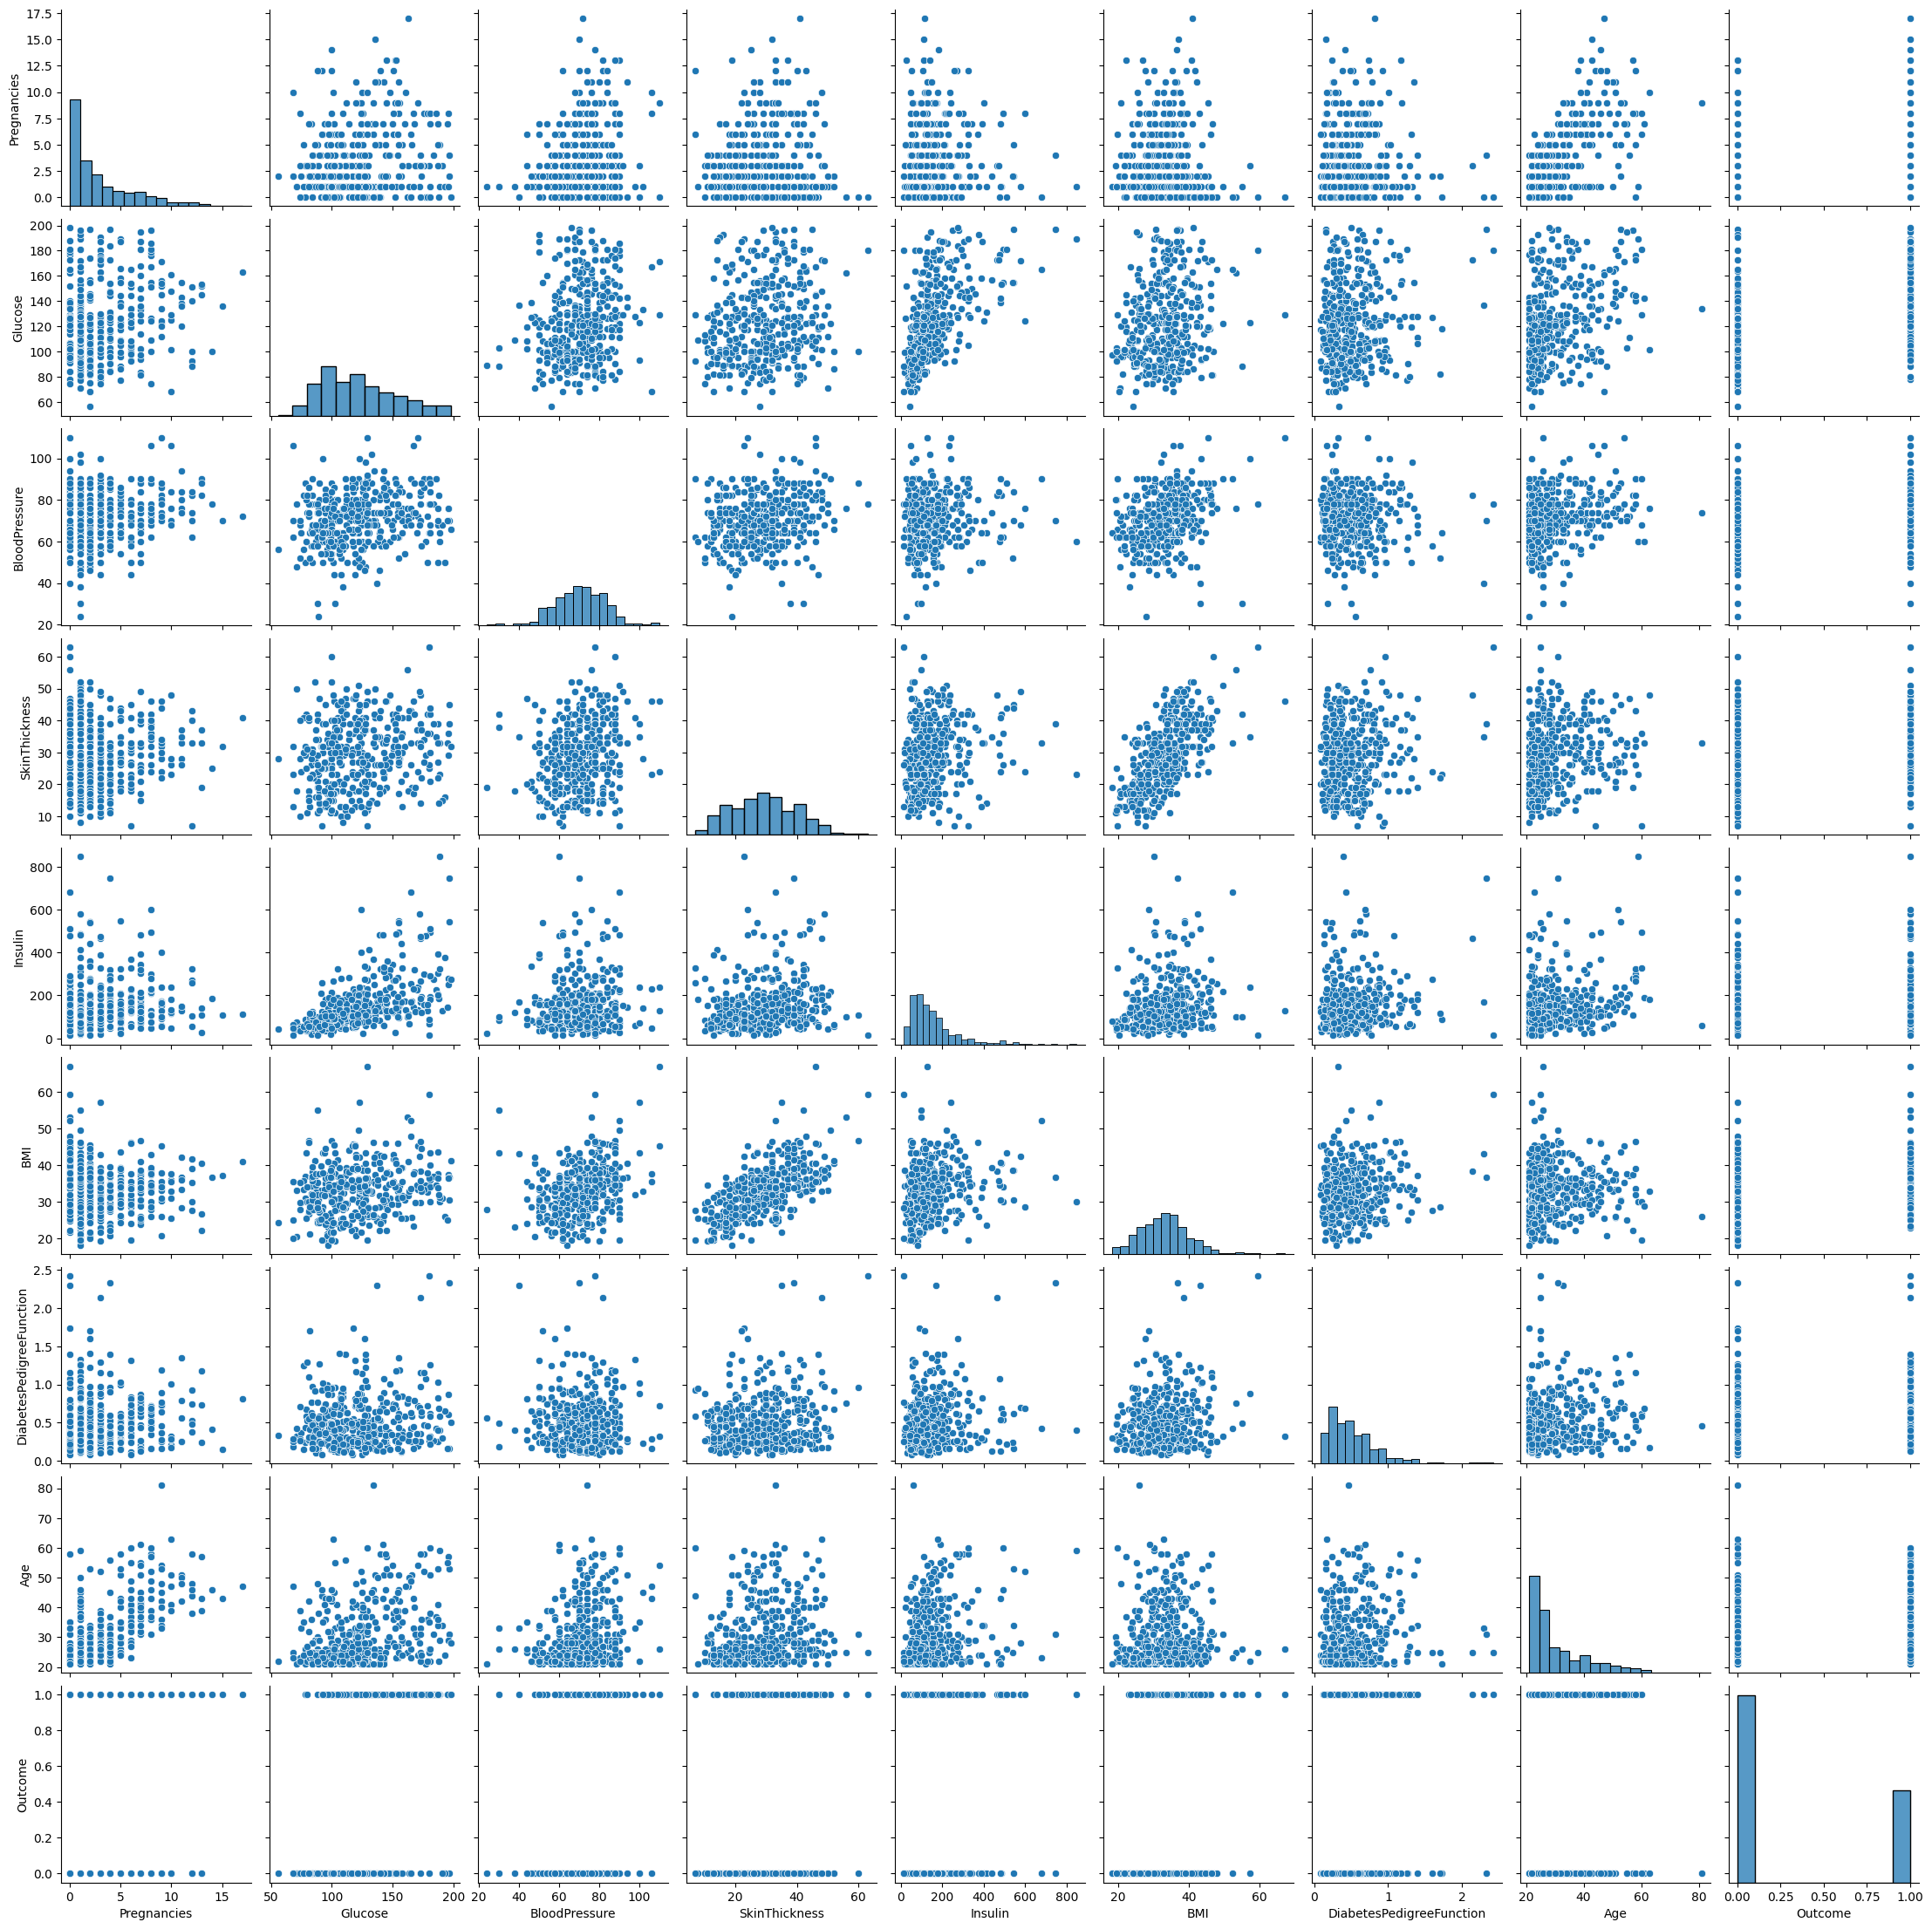

In [34]:
sns.pairplot(data = others)


### Strong Slope
1. Age vs pregnancies 
2. BMI vs Skin Thickness


### Moderate Slope
Insulin vs Glucose  - it's near verticl

### Weak slope


### Histograms
1. Pregnancy - right skew
2. Glucose - right skew
3. Blood pressure - near nornal
4. Skin thickness - near mormal, very very slight right skew
5. Insulin - heavy right skew
6. BMI near normal, but heavy right skew.
7. Diabetes pedigree function, right skew
8. Age - right skew
9. Outcome - 1s are about have of outome 0
 

### Correlations for the rest of patients without Insulin vs Glucose values 

In [41]:
others.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.198411,0.213740,0.095997,0.082171,-0.023913,-0.000402,0.680920,0.258846
Glucose,0.198411,1.000000,0.210148,0.198987,0.581186,0.209516,0.136723,0.343592,0.515632
BloodPressure,0.213740,0.210148,1.000000,0.232342,0.098272,0.303626,-0.020834,0.299845,0.192819
SkinThickness,0.095997,0.198987,0.232342,1.000000,0.184888,0.664916,0.154056,0.170694,0.257854
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261,0.303454
BMI,-0.023913,0.209516,0.303626,0.664916,0.228050,1.000000,0.159833,0.071566,0.271120
DiabetesPedigreeFunction,-0.000402,0.136723,-0.020834,0.154056,0.130395,0.159833,1.000000,0.076609,0.200759
Age,0.680920,0.343592,0.299845,0.170694,0.220261,0.071566,0.076609,1.000000,0.352982
Outcome,0.258846,0.515632,0.192819,0.257854,0.303454,0.271120,0.200759,0.352982,1.000000


### strong corr 0.5+
1. Age vs Pregnancies 0.68
2. BMI vs Skin thickness 0.66
3. Insulin vs Glucose 0.58
4. Glucose vs outcome 0.51

### moderate cor 0.3 to 0.4
1. BMI vs blood pressure 0.3
2. Insulin vs Outcome 0.30
3. glucose vs age 0.34
4. Age vs Outcome 0.35

### weak cor -0.3
1. Outcome vs Preg 0.25
2. Blood pressure vs pregnancues 0.21
3. Blood pressure vs Glucose 0.21
4. Blood pressure vs Pregnancies 0.21
5. Bood pressure vs Skin thickness 0.23
6. Age vs Blood pressure 0.29
7. Skin THickness vs Outcome 0.25
8. BMI vs Insulin 0.22
9. BMI vs Outcome 0.27
10. DPF vs Outcome 0.20
11. Insulin vs age 0.22
12. Outcome vs skin thickness 0.25


Overal correlations are back up again.


Given:
1. 227 out of 768 patients (%) had missing SkinThickness values.
2. 394 out of 768 patients (49%) had missing Insulin values.
3. All individuals with missing Skin Thickness values, also had missing Insulin values, leaving 147 out of 394 patients without the vice-versa
5. 33 out of 35 patients with missing Blood pressure values also had missing values for BOTH Insulin and SkinThickness.
4. for patients with BOTH missing Insulin and SkinThickness values, a larger portion of their subset (49%) had more than 4 pregnancies, with the second highest being the insulin only subset (39% of the subset) as compared to all others without missing insulin and SkinThicness values (27%)
5. All other comparisons between the insulin only subset, Skinthickness and insulin only subset and the rest of the total population did not display any large differences in values.


We can conclude that the the missingnss was not completely at random (MCAR), with evidence of missingness being related to other observed variables (ie: pregnancies), however, we do not know if the observed variables fully explain the missingness (MAR), and the possibility of (MNAR) cannot be ruled out.

The missing values w

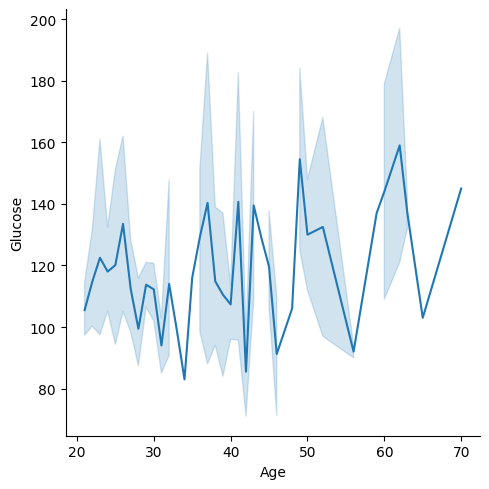

In [35]:
insulin_only = df.loc[(df["SkinThickness"].notna()) & (df["Insulin"].isna())]
sns.relplot(data = insulin_only, x = "Age", y = "Glucose", kind = "line" )

| Variable | Low | Normal | High / Risk |
|----------|-----|--------|-------------|
| Pregnancies | 0 | 1–4 (typical reproductive range) | >4 (higher parity) |
| Glucose (mg/dL) | <70 (hypoglycemia) | 70–99 | 100–125 (prediabetes), ≥126 (diabetes) |
| BloodPressure (mmHg) | <60 (low) | 60–80 | 80–89 (elevated), ≥90 (hypertension) |
| SkinThickness (mm) | Very low (<10) | 10–40 | >40 (high subcutaneous fat) |
| Insulin (µIU/mL) | <16 (low) | 16–166 | >166 (hyperinsulinemia) |
| BMI | <18.5 (underweight) | 18.5–24.9 | 25–29.9 (overweight), ≥30 (obese) |
| DiabetesPedigreeFunction | ~0–0.2 (low risk) | 0.2–0.8 | >0.8 (high genetic risk) |
| Age (years) | <30 (low risk group) | 30–45 | >45 (higher risk) |
| Outcome | 0 | — | 1 = diabetic |


Determinine if patients with missing variables had an outcome of 1

In [36]:


((df["SkinThickness"] == 0) & (df["Insulin"] == 0)).groupby(df['Outcome']).sum()

#(df[["SkinThickness", "Insulin"]] == 0).groupby(df["Outcome"]).sum()

Outcome
0    0
1    0
dtype: int64

out of those 227, 139 were found to be non-diabetic, with 88 diabetic

In [37]:
#df.loc[(df["Glucose"] > 140) & (df["Insulin"] == 0)]


df.loc[(df["SkinThickness"] == 0) & (df["Insulin"] == 0)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


All 227 patients with Skin Thickness of zero also recorded Insuline values of 0

i dont want to replace the missing values with NaN because of SkinThickness and Insulin parameters.
How do i check if these missing values are random?
- are there other missing values from the same patients in the data set?
- do individuals with these missing vallues also hav
- do these people with missing values have an outcome of 1 or zero?

In [38]:
df = df[colms].replace(0, np.nan)

NameError: name 'colms' is not defined